<a href="https://colab.research.google.com/github/khilan16/khilan16/blob/main/Comprehensive_EDA_and_Inferential_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [61]:
df=pd.read_csv('/content/global_cancer_patients_2015_2024.csv')

In [62]:
df.head(5)

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [64]:
df.duplicated().sum()

np.int64(0)

#Descriptive Analysis

#Age Column

###Ploting for age columns


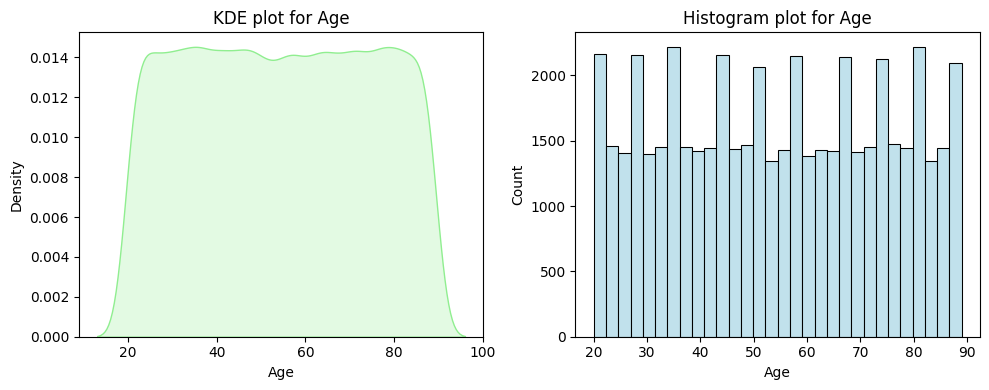

In [65]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data=df,x='Age',fill=True,color="lightgreen")
plt.title('KDE plot for Age')

plt.subplot(1,2,2)
sns.histplot(data=df,x='Age',bins=30,color='lightblue')
plt.title('Histogram plot for Age')
plt.tight_layout()
plt.show()

In [66]:
df['Age'].describe()

,Age
count,50000.000000
mean,54.421540
std,20.224451
min,20.000000
25%,37.000000
50%,54.000000
75%,72.000000
max,89.000000


# 📊 Age Column Analysis

## Descriptive Statistics

- **Total Records:** 50,000
- **Minimum Age:** 20 years
- **Maximum Age:** 89 years
- **Mean Age:** 54.42 years
- **Median Age:** 54 years
- **Standard Deviation:** 20.22 years
- **25th Percentile (Q1):** 37 years
- **50th Percentile (Q2):** 54 years
- **75th Percentile (Q3):** 72 years

---

# 📈 Inference

- The **Age** column contains **50,000** valid records, indicating that the dataset is complete for this feature.
- Age values range from **20 to 89 years**, covering a wide range of individuals.
- The **mean age (54.42 years)** is very close to the **median age (54 years)**, indicating that the distribution is **balanced** with minimal skewness.
- The **standard deviation (20.22 years)** indicates a good spread of age values across the dataset.
- The histogram shows that the age values are **approximately uniformly distributed** across the available range.
- The KDE (Kernel Density Estimation) plot also supports this observation by showing a **smooth and nearly uniform distribution**.
- The percentile values (**Q1 = 37, Median = 54, Q3 = 72**) indicate that the observations are evenly distributed across different age groups.
- No significant outliers or unusual patterns are observed in the Age column.
- The Age feature is suitable for **demographic analysis, customer segmentation, feature engineering, and predictive modeling**.

---

# ✅ Conclusion

The **Age** column is **clean, complete, and well-distributed**. It does not exhibit significant skewness or extreme outliers, making it a reliable feature for **Exploratory Data Analysis (EDA)** and **Machine Learning** applications.

#Gender Column



In [67]:
df['Gender'].value_counts()

,count
Gender,
Male,16796
Female,16709
Other,16495


###Plotting For Gender Columns

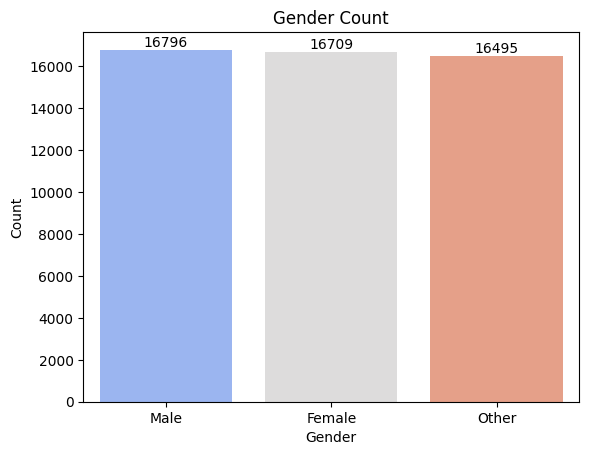

In [76]:
# plt.figure(figsize=(9,7))

sns.barplot(x=df['Gender'].value_counts().index,
                    y=df['Gender'].value_counts().values,
                    palette='coolwarm')
for i,v in enumerate(df['Gender'].value_counts()):
  plt.text(i,v,str(v),ha='center',va='bottom') # Corrected 'ho' to 'ha'

plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Inference – Gender Column

- The dataset contains **three gender categories**: Male, Female, and Other.
- **Male** has the highest number of records (**16,796**).
- **Female** has **16,709** records.
- **Other** has **16,495** records.
- The number of records is **almost equally distributed** across all three gender categories.
- There is **no significant class imbalance** in the Gender column.
- The Gender column is suitable for **gender-based analysis**.
- It can be used to analyze **survival trends**, **severity outcomes**, and compare results across different gender groups.

###Country columns

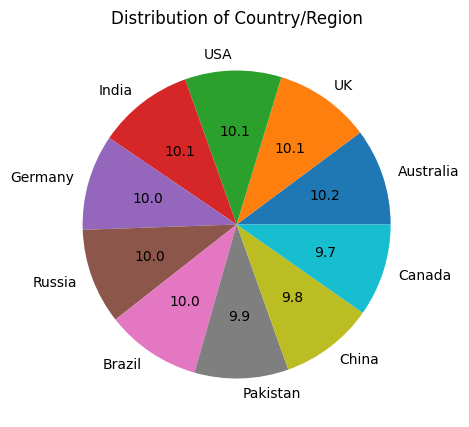

In [88]:
country_counts=df['Country_Region'].value_counts()
plt.figure(figsize=(10,5))
plt.pie(x=country_counts.values,
        labels=country_counts.index,
        autopct='%1.1f')
plt.title('Distribution of Country/Region')
plt.show()

# Inference: Country/Region Distribution

- The dataset contains patient records from **10 different countries/regions**.
- The distribution is **nearly uniform**, with each country contributing approximately **10%** of the total records.
- **Australia** has the highest number of records (around **10.2%**).
- **Canada** has the lowest share among the listed countries (around **9.7%**).
- The small variation in percentages indicates that the dataset is **well-balanced across countries**.
- A balanced country distribution reduces geographical bias in the analysis.
- This diversity enables reliable **cross-country comparisons** of cancer diagnosis, treatment outcomes, and survival trends.
- Overall, the dataset provides a **good representation of multiple regions**, making it suitable for global-level analysis.

Cancer Column

In [89]:
df['Cancer_Type'].value_counts()

,count
Cancer_Type,
Colon,6376
Prostate,6308
Leukemia,6266
Liver,6249
Skin,6231
Cervical,6222
Breast,6189
Lung,6159
